## APARTADO 3) BÚSQUEDA DE HILOS SIMILARES

El objetivo de este apartado es calcular y visualizar las similaridades que existen entre los hilos de cada subreddit y comprobar si algunos de estos hilos no "encajan" del todo en su comunidad o se desvían un poco de la idea general de esta.

In [36]:
import fasttext
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

Cargamos el modelo de FastText que nos hemos descargado de la página oficial de FastText preentrenado con un crawler de Internet y con granularidad de subpalabras.
Este modelo es correcto para realizar este apartado porque necesitamos un modelo que esté entrenado con contenido en inglés (porque la mayoría de nuestros hilos están en inglés), con especificidad para subpalabras (porque en estos hilos es probable que se encuentren palabras de jerga -*slang*- o palabras nuevas con las que no se ha entrenado el modelo y así tener una aproximación) y que sea lo suficientemente grande y general para abarcar los 6 subreddits que hemos seleccionado. 

In [37]:
# Cargamos el modelo en binario usando la librería fasttext.
ft_model = fasttext.load_model ("crawl-300d-2M-subword.bin")

Para poder comparar la similaridad entre hilos debemos de juntar todos los comentarios de cada hilo en un solo texto por hilo, y luego calcular sus sentence embeddings para poder aplicar la similaridad del coseno.

In [38]:
# Cargamos los datos (ejemplo con un subreddit)
books = pd.read_json('limpio_books.json')

# Extraemos y concatenamos comentarios por hilo
# La columna 'submissions' tiene una lista de hilos
# y dentro de cada hilo una lista de 'comments'
def preparar_texto_hilo(row):
    hilo = row['submissions']
    # Extraemos título
    titulo = str(hilo.get('title', ''))
    
    # Extraemos el cuerpo de todos los comentarios y los unimos con un join
    comentarios = hilo.get('comments', [])
    texto_comentarios = " ".join([str(c.get('body', '')) for c in comentarios])
    
    # Devolvemos todo unido en un solo string
    return f"{titulo} {texto_comentarios}".strip()

# Creamos la columna con el texto completo del hilo
books['texto_completo'] = books.apply(preparar_texto_hilo, axis=1)

# Obtenemos el vector (sentence embedding) para cada hilo
books['embedding'] = books['texto_completo'].apply(lambda x: ft_model.get_sentence_vector(x.replace('\n', ' ')))

In [39]:
books.head()

,subreddit,configuracion,submissions,texto_completo,embedding
0,books,59hilos_20com,"{'id_hilo': 0, 'comments': [{'author': 'Better...",Bibliophobia by Sarah Chihaya—it is both a dev...,"[0.006482005, -0.024207132, 0.04835908, 0.0103..."
1,books,59hilos_20com,"{'id_hilo': 1, 'comments': [{'author': 'MsKong...",I know a real child named Serendipity. All of ...,"[-0.00016156741, -0.01713391, 0.07899578, 0.00..."
2,books,59hilos_20com,"{'id_hilo': 2, 'comments': [{'author': 'eganba...",Every character in Wuthering Heights \n\nQvoth...,"[0.0017623894, -0.020752216, 0.06292402, 0.008..."
3,books,59hilos_20com,"{'id_hilo': 3, 'comments': [{'author': 'cherry...",Jeez that’s frustrating 😅\nGuess I better read...,"[0.0046107625, -0.021674851, 0.07579634, 0.007..."
4,books,59hilos_20com,"{'id_hilo': 4, 'comments': [{'author': 'TheMac...","**The House of Doors, by Brian Lumley**\n\nI o...","[0.0029786625, -0.018199977, 0.046426352, 0.00..."


Calculamos ahora la similaridad del coseno de estos sentence embeddings en una matriz y lo visualizamos en un mapa de calor. 

In [40]:
# Esto devuelve unamatriz de cuánto se parece cada hilo con todos los demás
matirz_similitud = cosine_similarity(list(books['embedding']))

<Axes: >

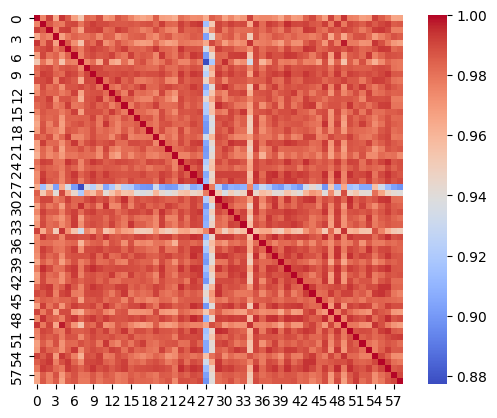

In [41]:
import seaborn as sns

sns.heatmap(matirz_similitud, annot=False, cmap='coolwarm', cbar=True, square=True)

Podemos observar en este mapa de calor que en este subreddit hay una gran similaridad entre hilos, sin embargo, se pueden distinguir tres hilos que se desvían un poco más de esta similaridad tan alta cerca de las lineas 3, 15 y 20, vamos a descubrir cuáles son exactamente.

In [42]:
# 1. Calculamos la media de similitud para cada fila (cada hilo)
# Restamos 1 porque la diagonal siempre es 1 (similitud consigo mismo)
mean_similarities = (matirz_similitud.sum(axis=1) - 1) / (matirz_similitud.shape[0] - 1)

# 2. Añadimos esta métrica a nuestro DataFrame original
books['similitud_media'] = mean_similarities

# 3. Ordenamos para ver los hilos MENOS similares al resto
hilos_intrusos = books.sort_values(by='similitud_media', ascending=True).head(3)

print("Hilos que menos encajan en el subreddit:")
print(hilos_intrusos[['texto_completo', 'similitud_media']])

Hilos que menos encajan en el subreddit:
                                       texto_completo  similitud_media
27  I’m rereading Blood Meridian for the 20th time...         0.920556
28  Starting **Green Grass, Running Water** by **T...         0.953844
34  Finished:\n\n**The Blue Castle, by L.M. Montgo...         0.964082


Descubrimos entonces que los 3 hilos que menos encajan en este subreddit son el 4, el 14 y el 19.

Ahora podemos representar estos vectores con un PCA de 2 dimensiones y ver una distribución en el espacio aproximada por estas dos primeras dimensiones de los hilos de este subreddit.

PCA

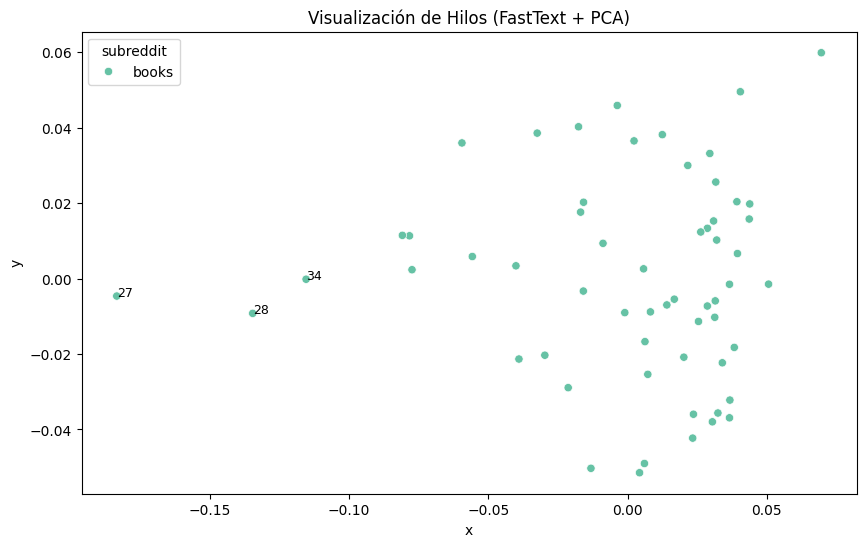

In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducimos dimensiones a 2D
pca = PCA(n_components=2)
puntos_2d = pca.fit_transform(list(books['embedding']))

# Añadimos las coordenadas al DataFrame para poder graficar
books['x'] = puntos_2d[:, 0]
books['y'] = puntos_2d[:, 1]

# Realizamos el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=books, x='x', y='y', hue='subreddit', palette='Set2')
plt.title("Visualización de Hilos (FastText + PCA)")

# Identificamos los puntos más lejanos
for i in range(len(books)):
    if books['similitud_media'].iloc[i] < books['similitud_media'].quantile(0.05): # El 5% "peor"
        plt.text(books['x'].iloc[i], books['y'].iloc[i], str(i), fontsize=9)

En este caso, las dos primeras dimensiones captan perfectamente esta "diferencia" de similaridad encontrada en este subreddit, pues es capaz de representar estos hilos que menos encajan más alejados del resto.

COMPLETO

Pasamos ahora a realizar este mismo análisis con los 6 subreddits extraídos a la vez.

In [44]:
import pandas as pd

archivos_json = [
    "limpio_travel.json", 
    "limpio_RandomThoughts.json", 
    "limpio_unpopularopinion.json",
    "limpio_jobs.json", 
    "limpio_books.json", 
    "limpio_LeagueOfLegends.json"
]

# Lista para ir guardando los dataframes temporales
lista_dfs = []

# Cargamos cada archivo y lo añadimos a la lista
for archivo in archivos_json:
    temp_df = pd.read_json(archivo)
    lista_dfs.append(temp_df)

# Concatenamos todo en un solo DataFrame
df_total = pd.concat(lista_dfs, ignore_index=True)

# Definimos la función para preparar el texto de cada hilo (título + comentarios)
def preparar_texto_hilo(row):
    hilo = row['submissions']
    titulo = str(hilo.get('title', ''))
    
    comentarios = hilo.get('comments', [])
    # Unimos comentarios y limpiamos saltos de línea (produce un error en FastText)
    texto_comentarios = " ".join([str(c.get('body', '')).replace('\n', ' ') for c in comentarios])
    
    return f"{titulo} {texto_comentarios}".strip().replace('\n', ' ')

# Procesamos los textos y generamos los embeddings para todos los hilos extraídos
df_total['texto_completo'] = df_total.apply(preparar_texto_hilo, axis=1)

df_total['embedding'] = df_total['texto_completo'].apply(lambda x: ft_model.get_sentence_vector(x))

print(f"Completado. Total de hilos procesados: {len(df_total)}")
display(df_total[['subreddit', 'texto_completo', 'embedding']].head())

Completado. Total de hilos procesados: 354


,subreddit,texto_completo,embedding
0,travel,I've made a few ;-) Probably the biggest less...,"[0.00399602, -0.0305757, 0.07388685, 0.0104076..."
1,travel,If it is easier to get a burger than the local...,"[0.00019570952, -0.01708065, 0.085167386, 0.00..."
2,travel,You meant Luton itself? Or was it that famous ...,"[0.0023312827, -0.022533527, 0.07625899, 0.005..."
3,travel,How did you fly into the country? Thank you ve...,"[0.0058110855, -0.025253866, 0.07398549, 0.005..."
4,travel,Boise Idaho. My kids live there and we visit f...,"[-0.00040546485, -0.016149554, 0.0789999, 0.01..."


Generamos ahora los mapas de calor para los 6 subreddits.

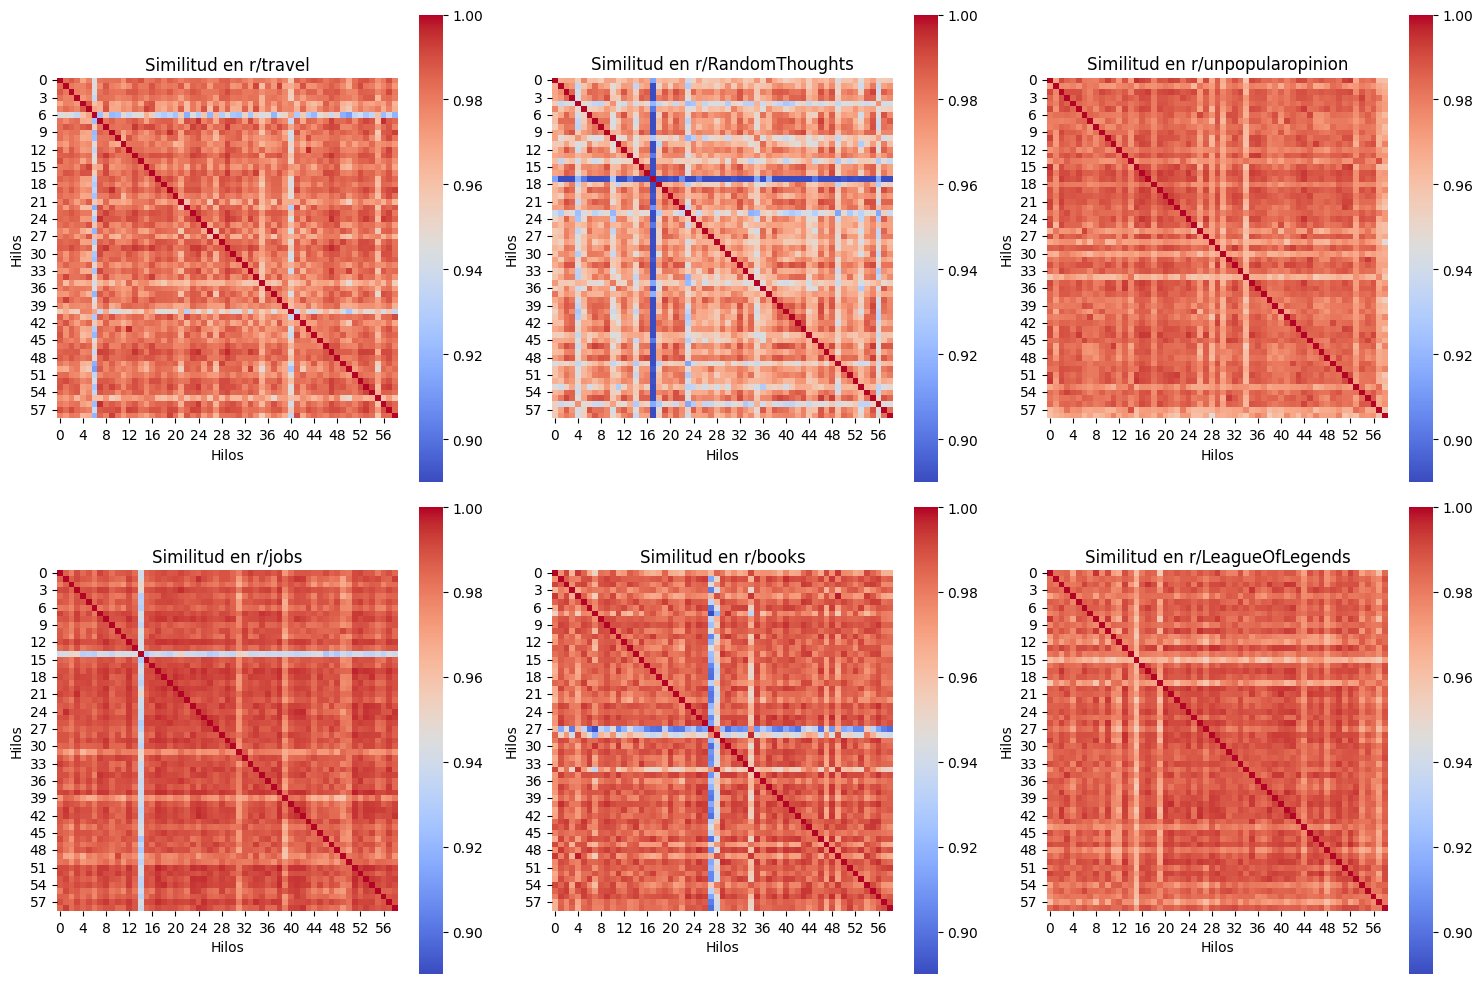

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

subreddits = df_total['subreddit'].unique()

ncols = 3
nrows = 2

# Preparamos la figura con subgráficos
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Iteramos sobre cada subreddit para generar su propio heatmap
for i, sub in enumerate(subreddits):
    # Filtramos los hilos que pertenecen solo a este subreddit
    df_sub = df_total[df_total['subreddit'] == sub]
    
    # Calculamos la matriz de similitud solo para esos hilos
    similitud_sub = cosine_similarity(list(df_sub['embedding']))
    
	# Calculamos la similitud media para cada hilo dentro de su subreddit para poder hacer el PCA posteriormente
    # y así solo iteramos por todo el dataset una vez
    mean_similarities = (similitud_sub.sum(axis=1) - 1) / (similitud_sub.shape[0] - 1)
    
    df_total.loc[df_total['subreddit'] == sub, 'similitud_media'] = mean_similarities
    
    # Dibujamos el heatmap
    sns.heatmap(similitud_sub, annot=False, cmap='coolwarm', ax=axes[i], 
                cbar=True, square=True, vmin=0.89)
    
    axes[i].set_title(f'Similitud en r/{sub}')
    axes[i].set_xlabel('Hilos')
    axes[i].set_ylabel('Hilos')

plt.tight_layout()
plt.show()

Gracias a esta gráfica podemos hacernos una idea de la similaridad general que tienen estos subreddits, siendo notable que la primera fila tiene unos colores más claros y azulados, indicando que son menos coherentes entre sí que los subreddits de la segunda fila, que tienen unos colores rojos más intensos lo que indica que son más compactos en cuanto a similaridad de sus hilos, a pesar de que estos cuenten con una diferencia absoluta mayor (líneas azul intenso), pero en general tienen valores más altos de similaridad.

Esto puede llegar a tener sentido si pensamos en los posibles hilos que se pueden generar en estos subreddits menos compactos. Tanto en **r/RandomThoughts** como en **r/unpopularopinion** se hablarán con frecuencia de temas muy dispares entre sí y con resultados también impredecibles, pues habrá comentarios apoyando los posts y otros criticándolo o con una discusión en los comentarios, tal vez otros hilos están teniendo una simple conversación, y al tener temas tan dispares pues ayuda a este índice más bajo de similaridad, siendo la más notable (y con más sentido) la comunidad de **r/RandomThoughts**. En **r/travel** entendemos a partir de estos resultados que pasa algo parecido, pero no creemos que sea algo de la naturaleza del subreddit, como sí creemos que es el caso de las otras dos comunidades. 

PCA

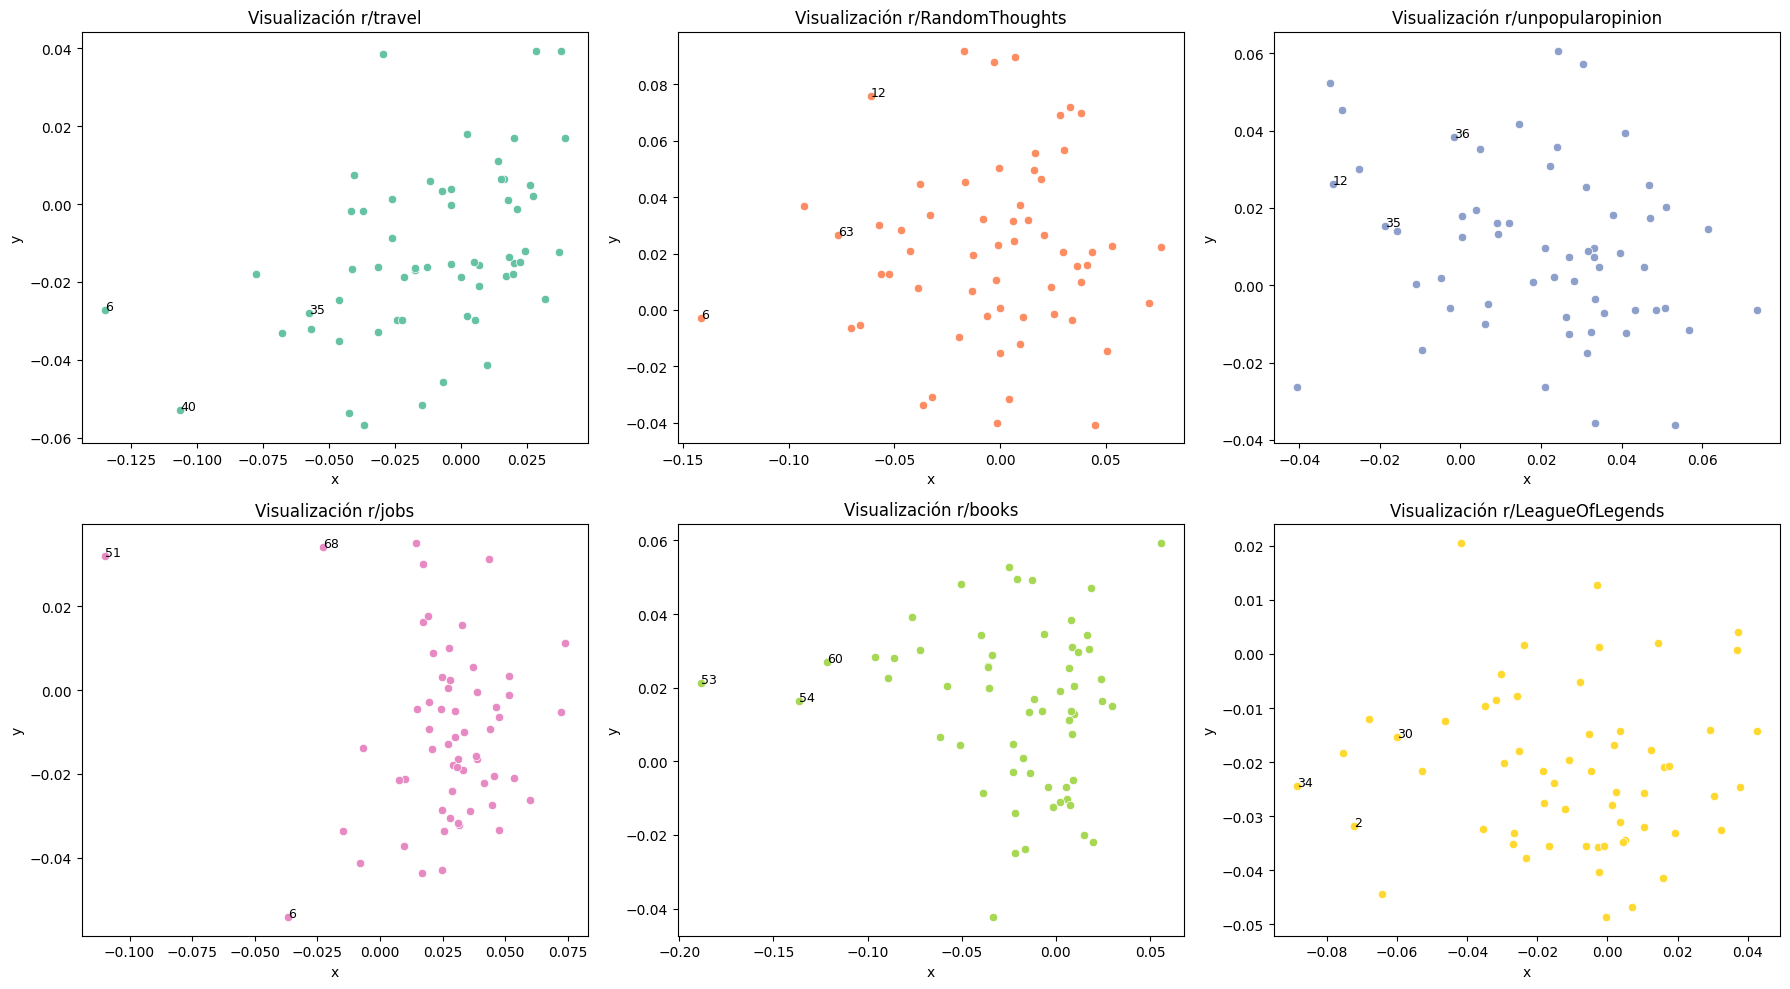

In [46]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducimos dimensiones a 2D
pca = PCA(n_components=2)
puntos_2d = pca.fit_transform(list(df_total['embedding']))

# Añadimos las coordenadas al DataFrame para poder graficar
df_total['x'] = puntos_2d[:, 0]
df_total['y'] = puntos_2d[:, 1]

# Preparamos la cuadrícula de subgráficas
subreddits = df_total['subreddit'].unique()
ncols = 3
nrows = 2

palette = sns.color_palette("Set2", len(subreddits))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() # Aplanamos para poder iterar fácilmente

# Dibujamosuna gráfica por cada subreddit
for i, sub in enumerate(subreddits):
    # Filtramos los datos solo para esta comunidad
    df_sub = df_total[df_total['subreddit'] == sub]
    
    # Dibujamos el scatterplot en el subgráfico correspondiente 
    sns.scatterplot(data=df_sub, x='x', y='y',color=palette[i], ax=axes[i])
    axes[i].set_title(f"Visualización r/{sub}")
    
    # Calculamos el 5% "peor" (menos similares) SOLO para este subreddit
    umbral_outliers = df_sub['similitud_media'].quantile(0.05)
    
    # Identificamos los puntos más lejanos
    for idx, row in df_sub.iterrows():
        if row['similitud_media'] < umbral_outliers:
            # Ponemos el índice original de cada subreddit
            axes[i].text(row['x'], row['y'], str(idx%70), fontsize=9, color='black')

plt.tight_layout()
plt.show()

Podemos observar que aunque en general los outliers corresponden con los puntos más alejados de la representación del PCA, no ocurre en todos los casos, como se ve en **r/unpopularopinion** (el más notable), pues la similaridad del coseno media con los hilos de su subreddit se calcula con todas las dimensiones del embedding, y puede ser que al "aplastar" todas esas dimensiones en solo 2 para poder representarlas, la diferencia que se ha calculado anteriormente no coincida visualmente con estas dos primeras dimensiones representadas, por eso vemos que los hilos menos similares en **r/unpopularopinion**, "visualmente" no están alejados en esta representación 2D.

También vemos que esta representación es coherente con los mapas de calor anteriores, pues los mapas de calor más oscuros corresponden con las gráficos más compactos y viceversa.